In [1]:
from pathlib import Path
from autogen.coding import LocalCommandLineCodeExecutor

# 1. Define the path correctly as a string inside Path()
# Use 'r' before the quotes to handle Windows backslashes properly
work_dir = Path(r"C:/Users/lucas/OneDrive - National University of Singapore/Modules/FYP/coding_outputs")

# 2. Create the directory if it doesn't exist
work_dir.mkdir(parents=True, exist_ok=True)

# 3. Create the executor
executor = LocalCommandLineCodeExecutor(work_dir=work_dir)

print(f"Executor ready. Files will be saved to: {work_dir}")

Executor ready. Files will be saved to: C:\Users\lucas\OneDrive - National University of Singapore\Modules\FYP\coding_outputs


In [ ]:
# %pip install gurobipy>=10
import gurobipy as gp
from gurobipy import GRB, Model


# %pip install autogen
import autogen
from autogen.agentchat import Agent, UserProxyAgent


# %pip install optiguide
from optiguide.optiguide import OptiGuideAgent

import pandas as pd
import numpy as np
import re
import requests  # for loading the example source code
import openai
import os
from dotenv import load_dotenv

import json
import requests
import time
from scipy.stats import norm
from pathlib import Path
from typing import Dict, Union, Optional


### Initialisation ###
load_dotenv()
# Prompt for the OpenAI key securely
API_KEY = os.getenv("API")
if not API_KEY:
    raise RuntimeError("Missing API environment variable 'API'")

# Build config in memory
llm_config = {
    "config_list": [
        {
            "model": "gpt-5-mini",
            "api_key": API_KEY,
        }
    ]
}

config_list = llm_config["config_list"]


###
### Optiguide Initialisation 
###

with open("source_code.py", "r", encoding="utf-8") as f:
    source_code = f.read()

with open("question_example.py", "r", encoding="utf-8") as f:
    example_qa = f.read()


optiguide_agent = OptiGuideAgent(name="OptiGuide",
                  source_code = source_code,
                   debug_times=3,
                  example_qa=example_qa,
                llm_config={
        "seed": 42,
        "config_list": config_list,
    })

user = UserProxyAgent("user", max_consecutive_auto_reply=1,
                         human_input_mode="ALWAYS", code_execution_config=False)

ans = user.initiate_chat(optiguide_agent, message = input("Please enter your inventory management query and I will get back to you: "))
answer_summary = ans.summary

In [31]:
from source_code import result_df
from graph_plot import generate_inventory_plot
import matplotlib.pyplot as plt

In [32]:
sku_list = list(result_df['SKU'].unique())
print(sku_list)

['212_Malaysia', '449_Australia', '797_Malaysia', '852_Australia', '864_Australia']


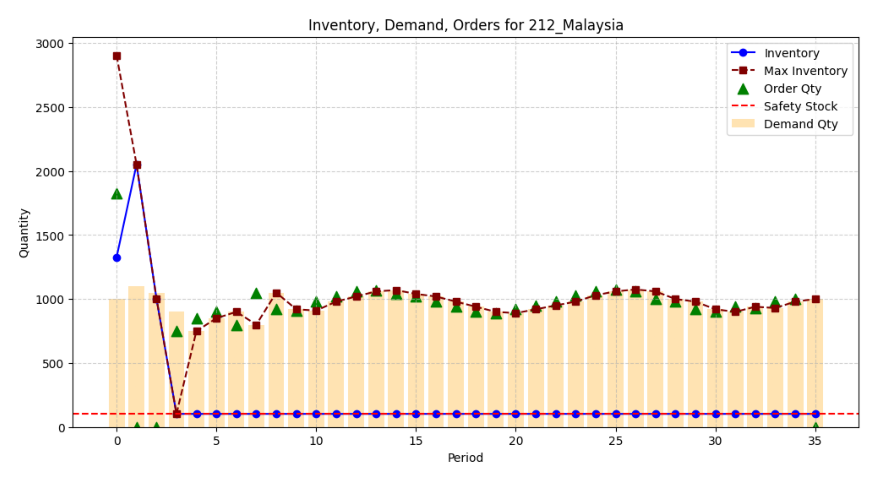

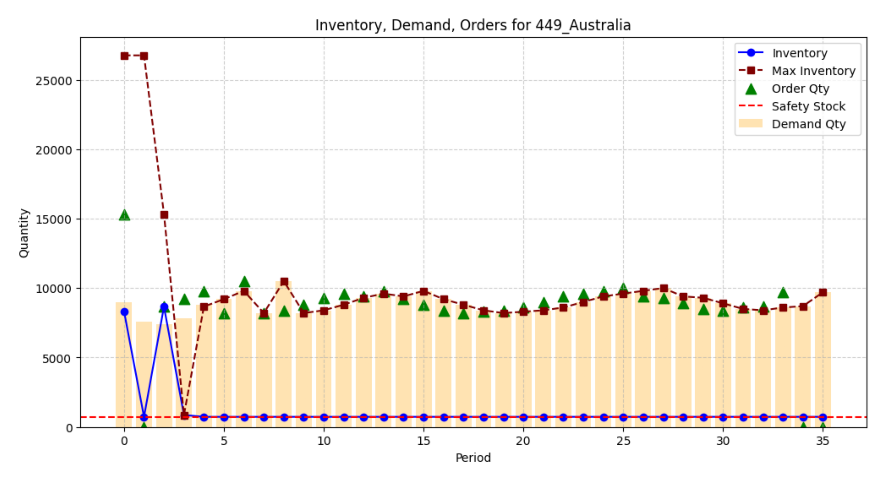

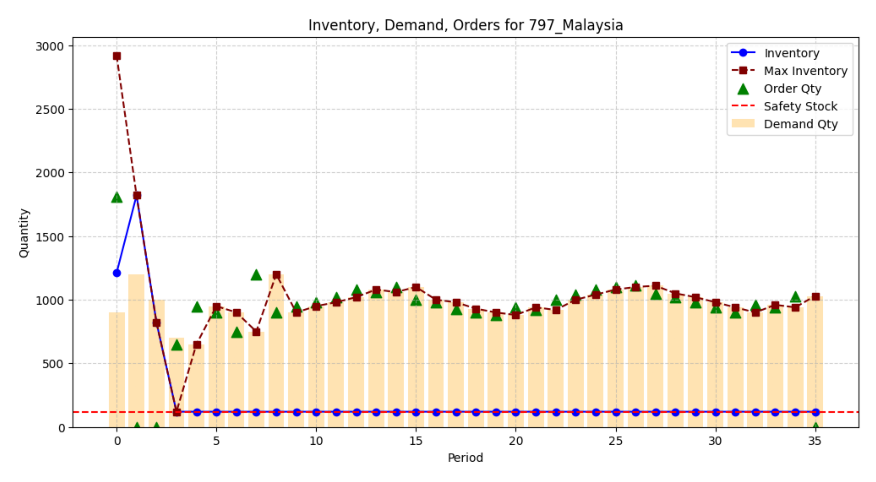

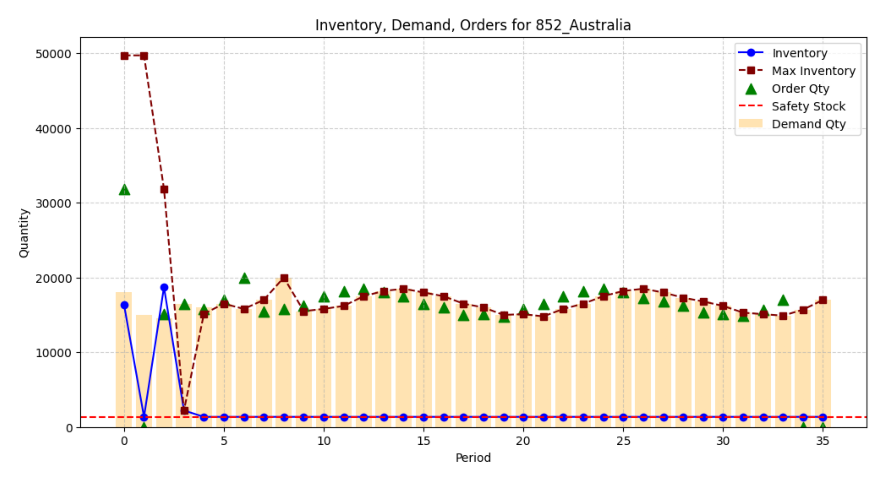

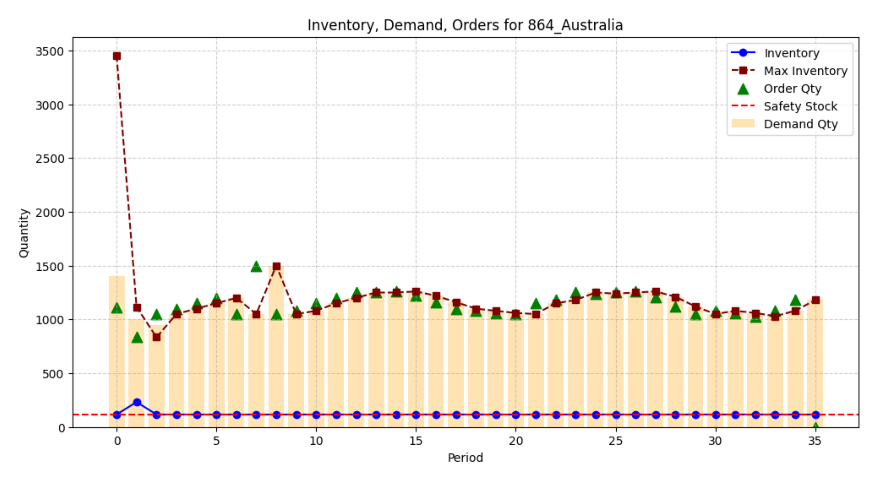

In [33]:
for sku in sku_list:
    buf = generate_inventory_plot(result_df, sku)

    # Display it locally
    import matplotlib.image as mpimg
    import matplotlib.pyplot as plt

    img = mpimg.imread(buf)
    plt.figure(figsize=(12,6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()